In [5]:
import h5py 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [96]:
Fs = 5000
ms_to_samples = lambda x: int(x / 1000 * Fs)

In [17]:
seq1 = np.asarray([1,1,1,1,2,1,2,1,2,1,1,2,1,1,1,2,1,1,1,1,1,1,1,2,1,1,1,2,1,1,1,1,2,1,1,2,1,1,2,1])
seq2 = np.asarray([1,2,1,1,1,2,1,1,1,2,1,1,2,1,1,2,1,1,1,1,2,1,1,1,2,1,2,1,1,1,1,1,2,1,1,1,1,2,1,1])
seq3 = np.asarray([1,1,1,1,1,2,1,1,1,2,1,2,1,1,1,2,1,1,2,1,1,1,1,2,1,1,1,2,1,1,2,1,1,2,1,1,1,1,1,2])
seq4 = np.asarray([1,2,1,1,1,1,1,1,2,1,1,2,1,1,2,1,1,1,1,2,1,2,1,1,1,2,1,1,2,1,1,1,1,2,1,2,1,1,1,1])

# 1 - motor, 2 - rest

In [171]:
def calculate_mep_amp(filename_path, bit, seq):
    with h5py.File(filename_path, "r") as h5f:
        data = h5f["eeg/data"][:-1]
    emg = data[:, 0]
    trigger = data[:, -1]
    ttl = np.array(trigger, dtype=np.uint8)
    trigger = ((ttl>>bit) & 0b1).astype(int)
    trigger_diff = np.diff(trigger)
    events = np.where(trigger_diff == 1)[0]
    def cut_epoch(timepoint, data, start, end):
        return data[timepoint+start:timepoint+end]

    start = ms_to_samples(-20)
    end = ms_to_samples(60)
    time = np.linspace(-20, 60, end-start)
    epochs = np.asarray([cut_epoch(timestamp, emg, start, end) for timestamp in events])

    def calculate_mep(epoch, time, from_ms=15, upto_ms=40):
        mask = (time >= from_ms) & (time <= upto_ms)
        if not np.any(mask):
            return np.nan
        data = epoch[mask]
        if data.size == 0 or not np.any(np.isfinite(data)):
            return np.nan
        return float(np.nanmax(data) - np.nanmin(data)) 
    amps = np.asarray([calculate_mep(epoch, time) for epoch in epochs]) * 1e3

    motor_amps = amps[np.where(seq == 1)]
    rest_amps = amps[np.where(seq == 2)]

    print(f"Средняя амплитуда МВП в покое была {np.mean(rest_amps):.3f} мВ. Медиана: {np.median(rest_amps):.3f} мВ.")
    print(f"Средняя амплитуда МВП при движении была {np.mean(motor_amps):.3f} мВ. Медиана: {np.median(motor_amps):.3f} мВ.")

    def baseline_correction(epochs, time, from_ms=-20, to_ms=-5):
        mask = np.where((time > from_ms) & (time<to_ms))[0]
        baseline_mean = np.mean(epochs[:, mask], axis=1)
        return epochs - baseline_mean.reshape((-1, 1))

    bas_epochs = baseline_correction(epochs, time)

    bas_motor_epochs = bas_epochs[np.where(seq == 1)] * 1e3
    bas_rest_epochs = bas_epochs[np.where(seq == 2)] * 1e3

    return bas_motor_epochs, bas_rest_epochs

In [208]:
subject = "02NS"

record = "07_tms_68MSO_real.hdf"
seq = seq1
filename_path = os.path.join(r"../data", subject, record)
print(f"-----Испытуемый {subject}, запись {record}-----")
motor_rmt_real, rest_rmt_real = calculate_mep_amp(filename_path, 2, seq1)


record = "08_tms_50MSO_real.hdf"
seq = seq2
filename_path = os.path.join(r"../data", subject, record)
print(f"-----Испытуемый {subject}, запись {record}-----")
motor_quasi_real, rest_quasi_real = calculate_mep_amp(filename_path, 2, seq2)


record = "09_tms_68MSO_MI.hdf"
seq = seq3
filename_path = os.path.join(r"../data", subject, record)
print(f"-----Испытуемый {subject}, запись {record}-----")
motor_rmt_mi, rest_rmt_mi = calculate_mep_amp(filename_path, 2, seq3)

record = "10_tms_50MSO_MI.hdf"
seq = seq4
filename_path = os.path.join(r"../data", subject, record)
print(f"-----Испытуемый {subject}, запись {record}-----")
motor_quasi_mi, rest_quasi_mi = calculate_mep_amp(filename_path, 2, seq4)


-----Испытуемый 02NS, запись 07_tms_68MSO_real.hdf-----
Средняя амплитуда МВП в покое была 0.998 мВ. Медиана: 0.846 мВ.
Средняя амплитуда МВП при движении была 2.995 мВ. Медиана: 2.927 мВ.
-----Испытуемый 02NS, запись 08_tms_50MSO_real.hdf-----
Средняя амплитуда МВП в покое была 0.104 мВ. Медиана: 0.104 мВ.
Средняя амплитуда МВП при движении была 0.826 мВ. Медиана: 0.837 мВ.
-----Испытуемый 02NS, запись 09_tms_68MSO_MI.hdf-----
Средняя амплитуда МВП в покое была 0.333 мВ. Медиана: 0.199 мВ.
Средняя амплитуда МВП при движении была 1.233 мВ. Медиана: 0.641 мВ.
-----Испытуемый 02NS, запись 10_tms_50MSO_MI.hdf-----
Средняя амплитуда МВП в покое была 0.122 мВ. Медиана: 0.124 мВ.
Средняя амплитуда МВП при движении была 0.203 мВ. Медиана: 0.129 мВ.


In [209]:
start = ms_to_samples(-20)
end = ms_to_samples(60)
time = np.linspace(-20, 60, end-start)

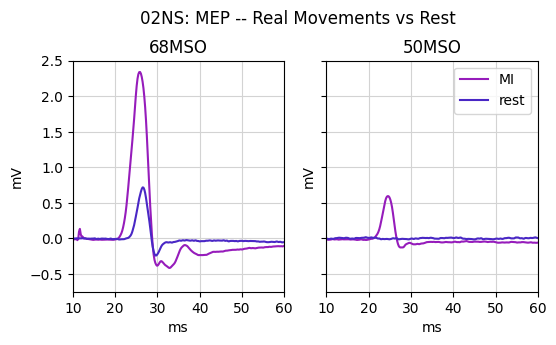

In [215]:
fig, axis = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
ax = axis[0]
ax.plot(time, -np.mean(motor_rmt_real, axis=0), label='MI (n=30)', color="#961CBB")
ax.plot(time, -np.mean(rest_rmt_real, axis=0), label='rest (n=10)', color="#4927C5")
ax.set_title("68MSO")


ax = axis[1]
ax.plot(time, -np.mean(motor_quasi_real, axis=0), label='MI', color="#961CBB")
ax.plot(time, -np.mean(rest_quasi_real, axis=0), label='rest', color="#4927C5")
ax.set_title("50MSO")
ax.legend()
plt.suptitle("02NS: MEP -- Real Movements vs Rest", y=1.05)

for ax in axis:
    ax.set_xlim(10, 60)
    ax.set_xlabel("ms")
    ax.set_ylabel("mV")
    ax.set_ylim(-0.75, 2.5)
    ax.grid(color='lightgrey')

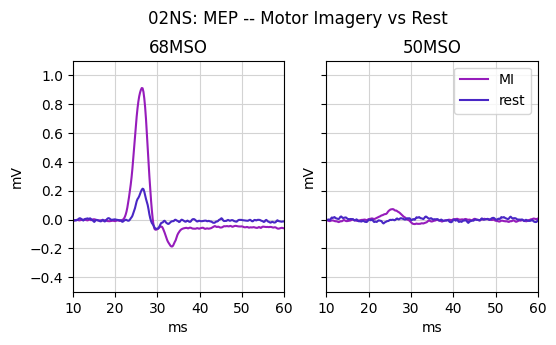

In [217]:
fig, axis = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
ax = axis[0]
ax.plot(time, -np.mean(motor_rmt_mi, axis=0), label='MI (n=30)', color="#961CBB")
ax.plot(time, -np.mean(rest_rmt_mi, axis=0), label='rest (n=10)', color="#4927C5")
ax.set_title("68MSO")


ax = axis[1]
ax.plot(time, -np.mean(motor_quasi_mi, axis=0), label='MI', color="#961CBB")
ax.plot(time, -np.mean(rest_quasi_mi, axis=0), label='rest', color="#4927C5")
ax.set_title("50MSO")
ax.legend()
plt.suptitle("02NS: MEP -- Motor Imagery vs Rest", y=1.05)

for ax in axis:
    ax.set_xlim(10, 60)
    ax.set_xlabel("ms")
    ax.set_ylabel("mV")
    ax.set_ylim(-0.5, 1.1)
    ax.grid(color='lightgrey')